In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
df = pd.read_csv("price_rating_playtime_regression.csv")  
df

,name,price,positive_ratings,negative_ratings,average_playtime,net_ratings
0,Counter-Strike,7.19,124534,3339,17612,121195
1,Team Fortress Classic,3.99,3318,633,277,2685
2,Day of Defeat,3.99,3416,398,187,3018
3,Deathmatch Classic,3.99,1273,267,258,1006
4,Half-Life: Opposing Force,3.99,5250,288,624,4962
5,Ricochet,3.99,2758,684,175,2074
6,Half-Life,7.19,27755,1100,1300,26655
7,Counter-Strike: Condition Zero,7.19,12120,1439,427,10681
8,Half-Life: Blue Shift,3.99,3822,420,361,3402
9,Half-Life 2,7.19,67902,2419,691,65483


In [24]:
df_filtered = df[df['average_playtime'] < 2000]

X_filtered = df_filtered[['price', 'positive_ratings', 'negative_ratings']]
y_filtered = df_filtered['average_playtime']

model_filtered = LinearRegression()
model_filtered.fit(X_filtered, y_filtered)



print("Intercept (β₀):", model.intercept_)
print("Coefficients (β₁, β₂, β₃):", model.coef_)
print("R² score:", model.score(X, y))

Intercept (β₀): 276.6601123601474
Coefficients (β₁, β₂, β₃): [ 5.89730071e+01  2.76542059e-02 -9.69606037e-02]
R² score: 0.17752426701318125


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


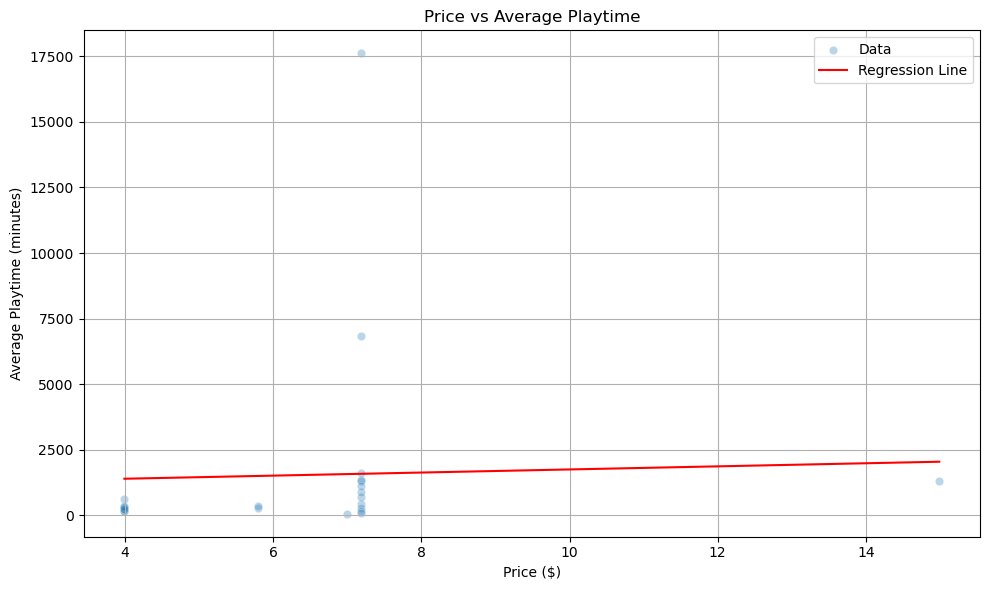

In [32]:
import os


os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['price'], y=df['average_playtime'], alpha=0.3, label='Data')

# Regresyon çizgisi: diğer iki değişken sabit tutulur
price_range = np.linspace(df['price'].min(), df['price'].max(), 100).reshape(-1, 1)
X_mean_values = [[p[0], df['positive_ratings'].mean(), df['negative_ratings'].mean()] for p in price_range]
predicted_playtime = model.predict(X_mean_values)

plt.plot(price_range, predicted_playtime, color='red', label='Regression Line')

plt.title('Price vs Average Playtime')
plt.xlabel('Price ($)')
plt.ylabel('Average Playtime (minutes)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("figures/price_vs_playtime_regression.png", dpi=300)

plt.show()

NameError: name 'df_filtered' is not defined

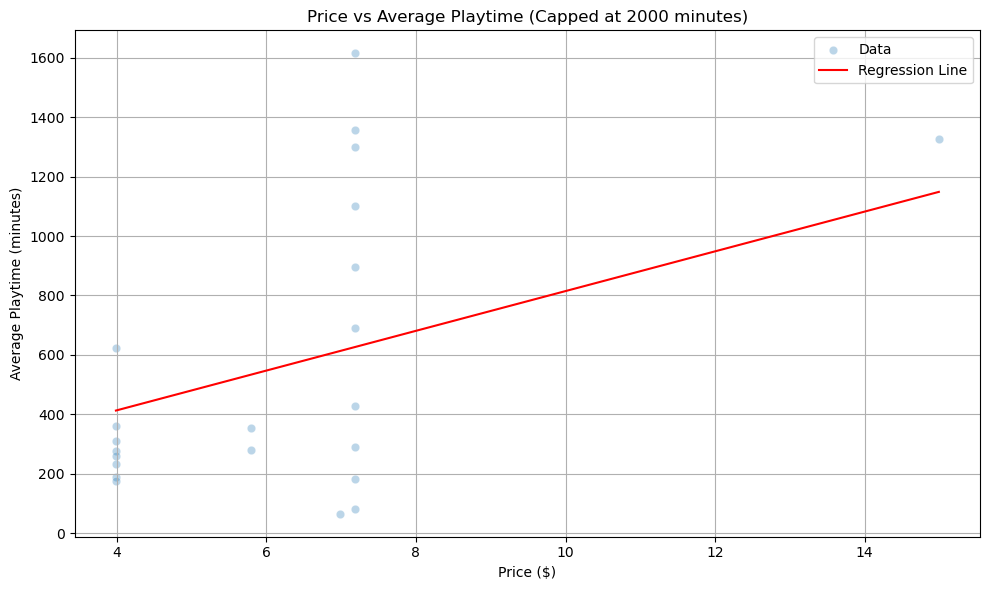

In [34]:
import os


os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_filtered['price'], y=df_filtered['average_playtime'], alpha=0.3, label='Data')

price_range = np.linspace(df_filtered['price'].min(), df_filtered['price'].max(), 100).reshape(-1, 1)
X_mean_values = [[p[0], df_filtered['positive_ratings'].mean(), df_filtered['negative_ratings'].mean()] for p in price_range]
predicted_playtime = model_filtered.predict(pd.DataFrame(X_mean_values, columns=['price', 'positive_ratings', 'negative_ratings']))

plt.plot(price_range, predicted_playtime, color='red', label='Regression Line')
plt.title('Price vs Average Playtime (Capped at 2000 minutes)')
plt.xlabel('Price ($)')
plt.ylabel('Average Playtime (minutes)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("figures/price_vs_playtime_regression_capped.png", dpi=300)

plt.show()